In [1]:
%pylab inline
%config InlineBackend.figure_format = 'retina'
from ipywidgets import interact
from scipy import sparse as sparse
from scipy.sparse import linalg as spla

Populating the interactive namespace from numpy and matplotlib


# Example: Applying a Dirichlet boundary condition to a curved boundary
$$ \nabla^2 u = -1, \quad x \in \Omega,$$
$$ \partial_n u = 0, \quad x \in \partial \Sigma,$$
$$ u = 0, \quad x \in \partial \Gamma_R,$$
where $\Sigma$ is the unit square, $\Gamma_R$ is the circle with radius $R$ centered at $(x, y) = (0.5, 0.5)$, and $\Omega = \Sigma \setminus \Gamma_R$.

In [66]:
R = 0.15
kappa = 1./22.

m = 100
h = 1/(m+1)
x = linspace(0, 1, m+2)
y = linspace(0, 1, m+2)
r2 = (x[None, :] - 0.5)**2 + (y[:, None] - 0.5)**2
grid_mask = r2 >= R**2 # we will also use this later to transfer back and forth between grid and unknown vector

## The right hand side
F = -ones((m+2)**2)/kappa

## Array to store the solution
u = zeros((m+2, m+2))

## we will use this to modify the matrix and RHS
def n_of_ij(i, j):
    """The linear index n for the matrix corresponding to the grid index i, j"""
    return i*(m+2) + j

## Initialize the finite difference matrix
## We have outer Neumann boundaries, so the unknowns include the boundaries of the grid
I = sparse.eye(m+2)
e = ones(m+2)
T = sparse.spdiags([e, -4*e, e], [-1, 0, 1], m+2, m+2)
S = sparse.spdiags([e, e], [-1, 1], m+2, m+2)
A = (sparse.kron(I, T) + sparse.kron(S, I))/h**2

# figure(1, [7, 7])
## block tridiagonal
# imshow(A.toarray().clip(-1, 1));

## We must now modify the finite differences for points on the inner boundary
We will assume that we have a boundary point to the left or right and correct the finite difference for the $x$ coordinate. The corresponding formulas for $y$ are then simply given by exchanging the variables $x$ and $y$.
### The corrected finite difference formula (see lecture notes for derivation)
Let $(x, y)$ be the position of the grid point. Let $x$ coordinate of the boundary to the left or right of the grid point be $x_B = x \pm \alpha h$, for $\alpha \in (0, 1)$.
$$\partial_x^2 u(x, y) \approx \frac{1}{h^2}\left(\frac{2}{\alpha+1} u_{W/E} - \frac{2}{\alpha}u_P + \frac{2}{\alpha(\alpha+1)}u_B\right)$$
where $u_B$ is the value of $u$ on the boundary (in our case $u_B=0$), $u_P = u(x, y)$, and $u_{W/E}$ is the neighboring grid point that is inside the domain to the west or east.

### Computing $\alpha$
Solve for the value of $\alpha$ for which the horizontal line 
$$ (x, y) \pm (\alpha h, 0) $$
passing through $(x, y)$ is exactly a distance $R$ from the center (i.e., where the line intersects the inner boundary).
$$  \left(x \pm \alpha h - \frac{1}{2}\right)^2+ \left(y - \frac{1}{2}\right)^2 = R^2 $$
Solving for the smallest root yields
$$ \alpha = \frac{1}{h}\left(\left\vert x - \frac{1}{2}\right\vert 
- \sqrt{R^2 - \left(y - \frac{1}{2}\right)^2}\right), $$
Likewise, we have
$$ \beta = \frac{1}{h}\left(\left\vert y - \frac{1}{2}\right\vert 
- \sqrt{R^2 - \left(y - \frac{1}{2}\right)^2}\right), $$
Out of this formula, we obtain a necessary condition for a grid point to be a boundary point. That is, if 
$$ \sqrt{\left(x - \frac{1}{2}\right)^2 + \left(y - \frac{1}{2}\right)^2} > R$$ 
and either $\alpha < 1$ or $\beta < 1$ then the point has a nearest neigbor grid point inside the inner boundary.

In [67]:
## Compute correction factors alpha and beta for the finite differences near the inner boundary
y_check = R**2 - (x[None, :] - 0.5)**2
x_check = R**2 - (y[:, None] - 0.5)**2
_alpha = (1/h)*(absolute(x[None, :] - 0.5) - sqrt(absolute(x_check)))
_beta = (1/h)*(absolute(y[:, None] - 0.5) - sqrt(absolute(y_check)))
inner_boundary_grid_mask_x = (x_check > 0)&(_alpha < 1)&grid_mask # vectorized boolean 'and' operator is `&`
inner_boundary_grid_mask_y = (y_check > 0)&(_beta < 1)&grid_mask
alpha = _alpha[inner_boundary_grid_mask_x]
beta = _beta[inner_boundary_grid_mask_y]

## loop over interior points to modify FD for points near the interior boundary
## Note: we don't need to correct points that will get deleted later

## Loop over points with a boundary on the left or right
for i, j, alpha_ij in zip(*where(inner_boundary_grid_mask_x), alpha):
    n = n_of_ij(i, j) # the linear index for the matrix corresponding to the grid index i, j
    A[n, n] += (2 - 2/alpha_ij)/h**2 ## use += because a grid point might have two neighbors that are boundary
    if x[j] > 0.5: # correct uE
        A[n, n_of_ij(i, j+1)] = 2/(1 + alpha_ij)/h**2
    else: # correct uW
        A[n, n_of_ij(i, j-1)] = 2/(1 + alpha_ij)/h**2
    ## We could correct F[n] for an inhomogeneous Dirichlet BC here
    
## Loop over points with a boundary above or below
for i, j, beta_ij in zip(*where(inner_boundary_grid_mask_y), beta):
    n = n_of_ij(i, j) # the linear index for the matrix corresponding to the grid index i, j
    A[n, n] += (2 - 2/beta_ij)/h**2 ## use += because a grid point might have two neighbors that are boundary
    if y[i] > 0.5: # correct uN
        A[n, n_of_ij(i+1, j)] = 2/(1 + beta_ij)/h**2
    else: # correct uS
        A[n, n_of_ij(i-1, j)] = 2/(1 + beta_ij)/h**2
    ## We could correct F[n] for an inhomogeneous Dirichlet BC here

## Adjust the matrix and RHS for outer Neumann boundary condition

In [68]:
i = j = arange(1, m+1) # just the interior points, corners handled seperately for clarity

## bottom edge
A[n_of_ij(0, j), n_of_ij(0, j)] = 1/h
A[n_of_ij(0, j), n_of_ij(1, j)] = -1/h
A[n_of_ij(0, j), n_of_ij(0, j+1)] = 0.
A[n_of_ij(0, j), n_of_ij(0, j-1)] = 0.
F[n_of_ij(0, j)] = -0.5*h ## correction for O(h^2) LTE at edges

## top edge
A[n_of_ij(m+1, j), n_of_ij(m+1, j)] = 1/h
A[n_of_ij(m+1, j), n_of_ij(m, j)] = -1/h
A[n_of_ij(m+1, j), n_of_ij(m+1, j+1)] = 0.
A[n_of_ij(m+1, j), n_of_ij(m+1, j-1)] = 0.
F[n_of_ij(m+1, j)] = -0.5*h

## left edge
A[n_of_ij(i, 0), n_of_ij(i, 0)] = 1/h
A[n_of_ij(i, 0), n_of_ij(i, 1)] = -1/h
A[n_of_ij(i, 0), n_of_ij(i+1, 0)] = 0.
A[n_of_ij(i, 0), n_of_ij(i-1, 0)] = 0.
F[n_of_ij(i, 0)] = -0.5*h

## right edge
A[n_of_ij(i, m+1), n_of_ij(i, m+1)] = 1/h
A[n_of_ij(i, m+1), n_of_ij(i, m)] = -1/h
A[n_of_ij(i, m+1), n_of_ij(i+1, m+1)] = 0.
A[n_of_ij(i, m+1), n_of_ij(i-1, m+1)] = 0.
F[n_of_ij(i, m+1)] = -0.5*h

## corners
A[n_of_ij(0, 0), n_of_ij(0, 0)] = 2/h
A[n_of_ij(0, 0), n_of_ij(1, 0)] = -1/h
A[n_of_ij(0, 0), n_of_ij(0, 1)] = -1/h
F[n_of_ij(0, 0)] = -0.25*h ## correction for O(h^2) LTE at corners

A[n_of_ij(m+1, m+1), n_of_ij(m+1, m+1)] = 2/h
A[n_of_ij(m+1, m+1), n_of_ij(m, m+1)] = -1/h
A[n_of_ij(m+1, m+1), n_of_ij(m+1, m)] = -1/h
F[n_of_ij(m+1, m+1)] = -0.25*h

A[n_of_ij(0, m+1), n_of_ij(0, m+1)] = 2/h
A[n_of_ij(0, m+1), n_of_ij(1, m+1)] = -1/h
A[n_of_ij(0, m+1), n_of_ij(0, m)] = -1/h
F[n_of_ij(0, m+1)] = -0.25*h

A[n_of_ij(m+1, 0), n_of_ij(m+1, 0)] = 2/h
A[n_of_ij(m+1, 0), n_of_ij(m, 0)] = -1/h
A[n_of_ij(m+1, 0), n_of_ij(m+1, 1)] = -1/h
F[n_of_ij(m+1, 0)] = -0.25*h

## Now we want to refine the matrix so that our unknown vector contains only grid points inside the domain (we need to exclude the grid points inside the inner boundary)

In [69]:
flat_mask = grid_mask.flatten()
A.shape, 52**2, flat_mask.shape, grid_mask.shape

((10404, 10404), 2704, (10404,), (102, 102))

In [70]:
import scipy

Ad = A.todense()
temp = Ad[flat_mask, :]
A_pruned = temp[:, flat_mask]
F_pruned = F[flat_mask]
A_pruned.shape, F_pruned.shape


ALU = scipy.linalg.lu_factor(A_pruned)

u[grid_mask] = scipy.linalg.lu_solve(ALU, F_pruned)

In [75]:
# flat_mask = grid_mask.flatten()

# A_pruned = A.tocsc()
# A_pruned = A_pruned[:, flat_mask].tocsr()
# A_pruned = A_pruned[flat_mask, :]

# F_pruned = F[flat_mask]

# figure(1, [7, 7])
# imshow(A_pruned.toarray().clip(-1, 1));
?spla.spsolve

## Solve

In [72]:
u[grid_mask] = spla.spsolve(A_pruned, F_pruned)
# u[~grid_mask] = nan

/usr/local/lib/python3.9/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:214: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',


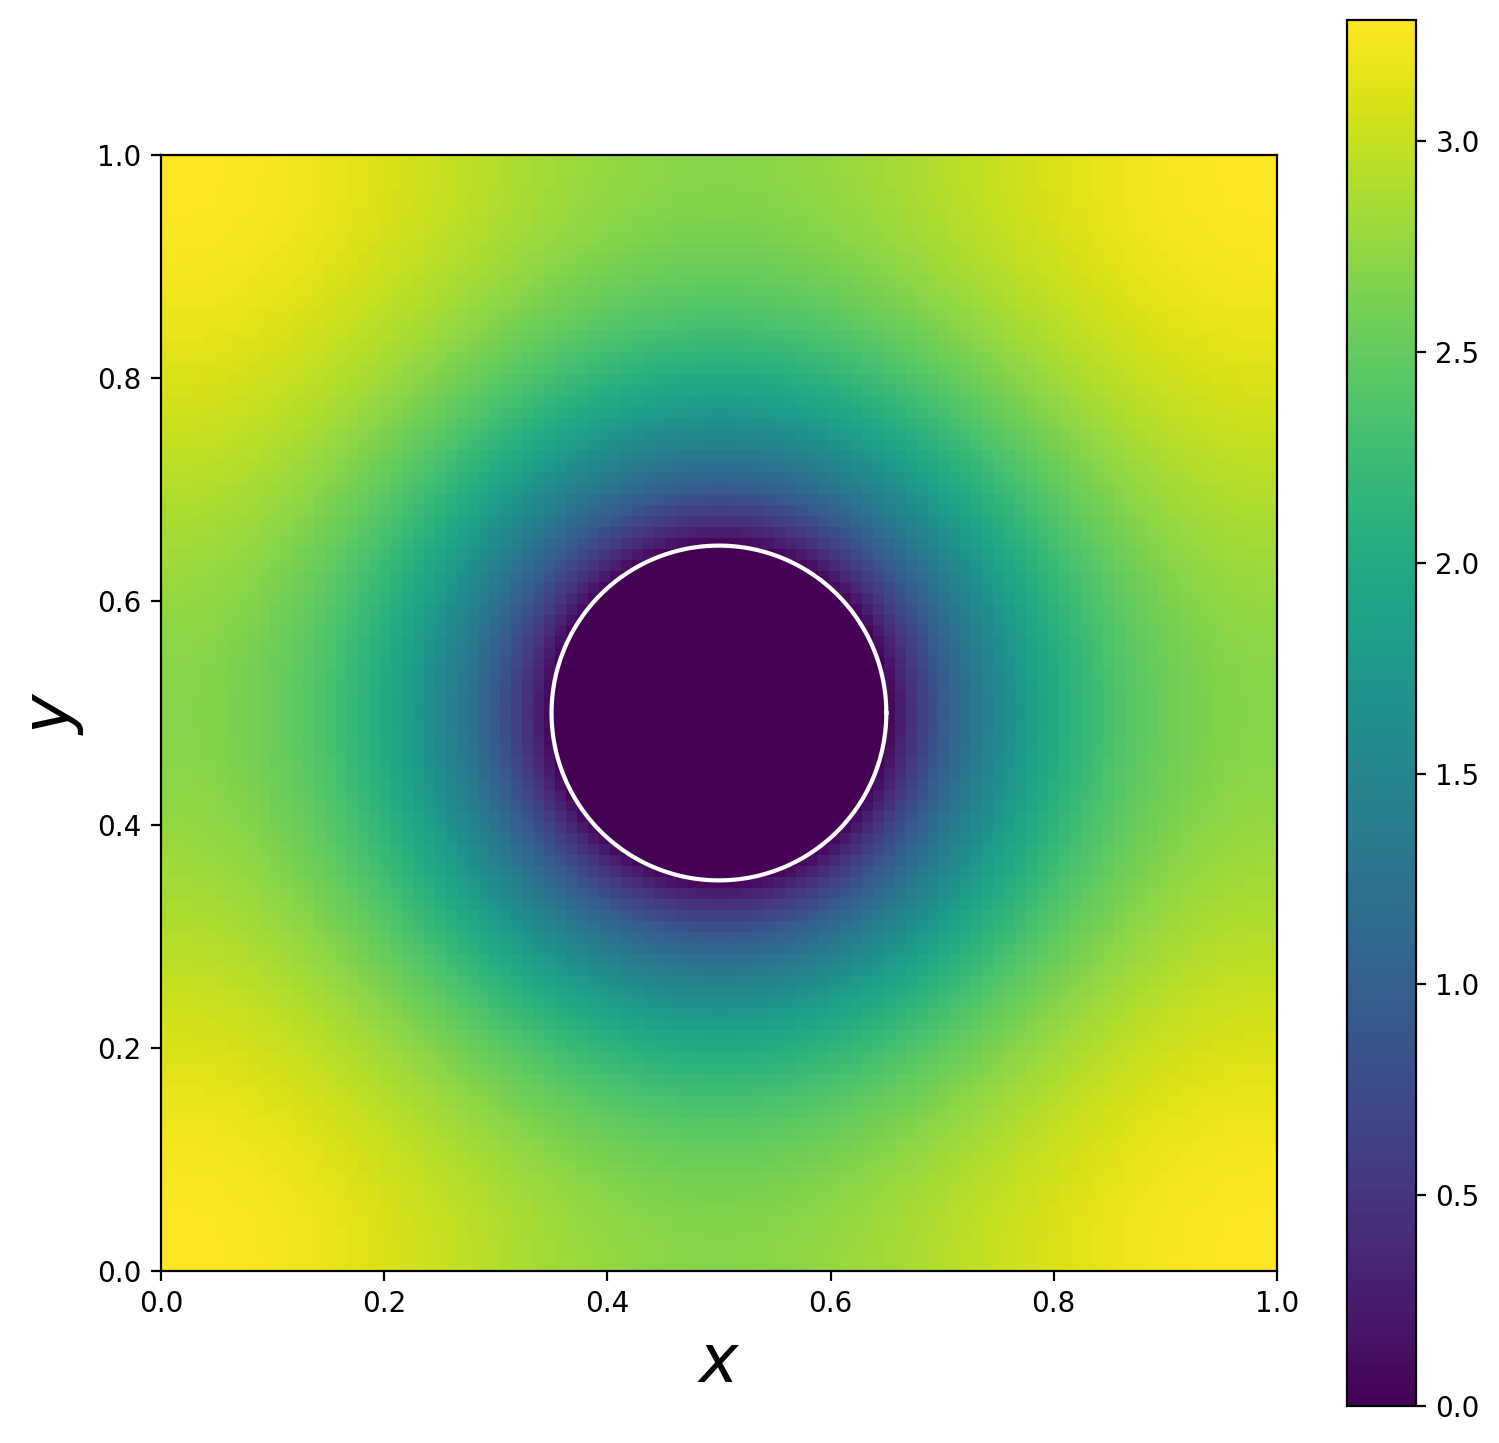

In [76]:
figure(1, [9, 9])
uplot = u.copy()
imshow(uplot, origin='lower', extent=[0, 1, 0, 1])
colorbar()
theta = linspace(0, 2*pi, 200)
plot(0.5 + R*cos(theta), 0.5 + R*sin(theta), 'w')
xlabel(r'$x$', fontsize=24)
ylabel(r'$y$', fontsize=24);

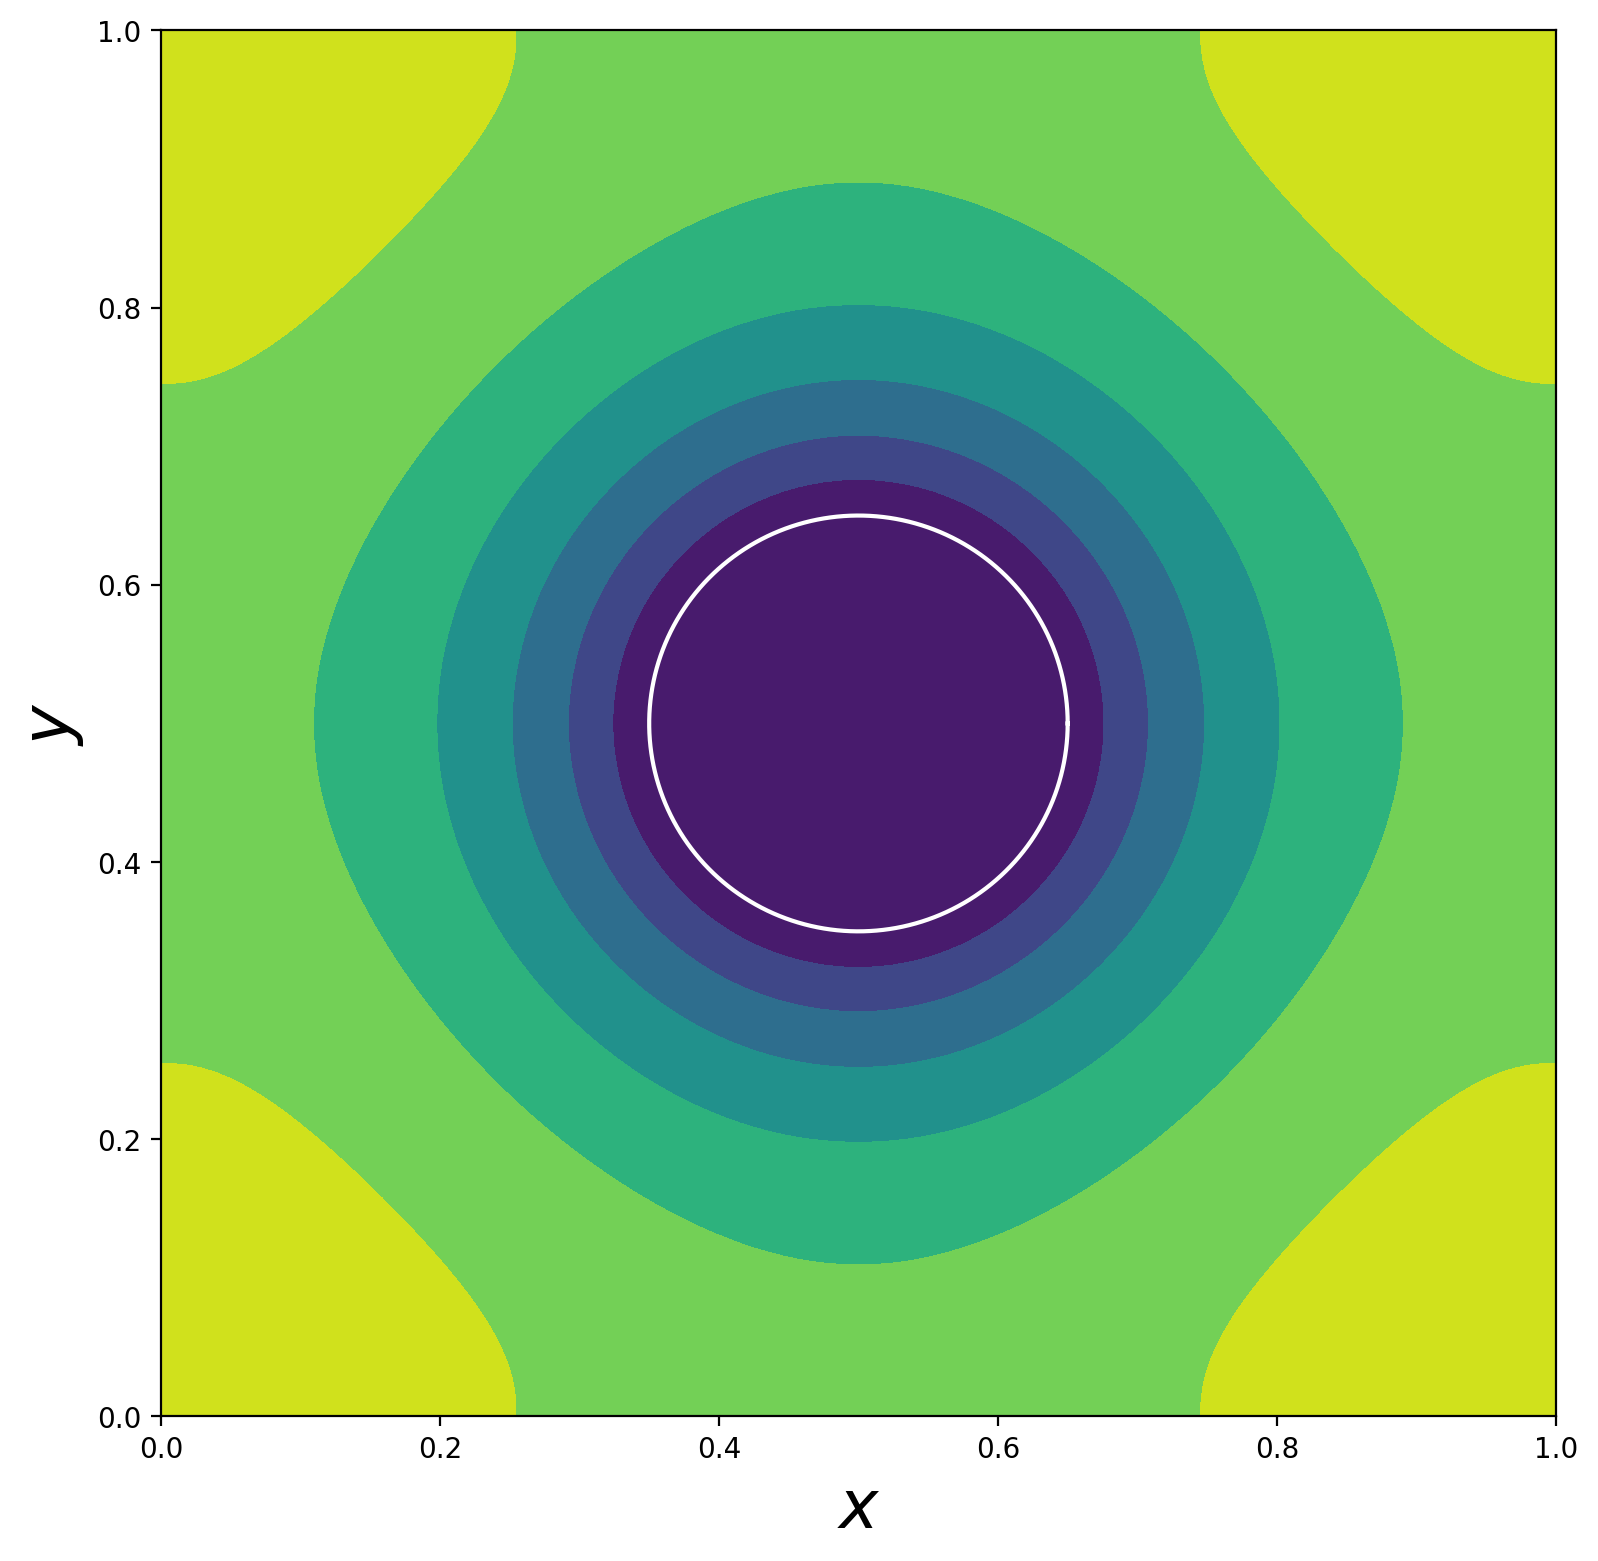

In [77]:
figure(1, [9, 9])
contourf(x, y, u)
# colorbar()
theta = linspace(0, 2*pi, 200)
plot(0.5 + R*cos(theta), 0.5 + R*sin(theta), 'w')
xlabel(r'$x$', fontsize=24)
ylabel(r'$y$', fontsize=24);

# Example: outer Dirichlet boundaries
Impose inhomogeneous Dirichlet boundary condition to the outer boundary
$$ u = u_T, \quad x \in \partial \Sigma $$
and to the inner boundary
$$u = u_R, \quad x \in \partial \Gamma_R $$
We also set the right hand side to $f(x, y) = 0$.

In [29]:
R = 0.05
uT = 22.
uR = -2.

m = 70
h = 1/(m+1)
x = linspace(0, 1, m+2)
y = linspace(0, 1, m+2)
r2 = (x[None, :] - 0.5)**2 + (y[:, None] - 0.5)**2
grid_mask = r2 >= R**2 # we will also use this later to transfer back and forth between grid and unknown vector

## The right hand side
F = -zeros(m**2)

## Array to store the solution
u = -uR*ones((m+2, m+2))
u[grid_mask] = uT

## we will use this to modify the matrix and RHS
def n_of_ij(i, j):
    """The linear index n for the matrix corresponding to the grid index i, j"""
    return (i - 1)*m + j - 1

## Initialize the finite difference matrix
I = sparse.eye(m)
e = ones(m)
T = sparse.spdiags([e, -4*e, e], [-1, 0, 1], m, m)
S = sparse.spdiags([e, e], [-1, 1], m, m)
A = (sparse.kron(I, T) + sparse.kron(S, I))/h**2

## Compute correction factors alpha and beta for the finite differences near the inner boundary
y_check = R**2 - (x[None, :] - 0.5)**2
x_check = R**2 - (y[:, None] - 0.5)**2
_alpha = (1/h)*(absolute(x[None, :] - 0.5) - sqrt(absolute(x_check)))
_beta = (1/h)*(absolute(y[:, None] - 0.5) - sqrt(absolute(y_check)))



inner_boundary_grid_mask_x = (x_check > 0)&(_alpha < 1)&grid_mask # vectorized boolean 'and' operator is `&`
inner_boundary_grid_mask_y = (y_check > 0)&(_beta < 1)&grid_mask
alpha = _alpha[inner_boundary_grid_mask_x]
beta = _beta[inner_boundary_grid_mask_y]

## loop over interior points to modify FD for points near the interior boundary
## Note: we don't need to correct points that will get deleted later

## Loop over points with a boundary on the left or right
## If we had inhomogeneous boundary condition on the inner boundary, we could modify the RHS here
for i, j, alpha_ij in zip(*where(inner_boundary_grid_mask_x), alpha):
    n = n_of_ij(i, j) # the linear index for the matrix corresponding to the grid index i, j
    A[n, n] += (2 - 2/alpha_ij)/h**2 ## use += because a grid point might have two neighbors that are boundary
    if x[j] > 0.5: # correct uE
        A[n, n_of_ij(i, j+1)] = 2/(1 + alpha_ij)/h**2
    else: # correct uW
        A[n, n_of_ij(i, j-1)] = 2/(1 + alpha_ij)/h**2
    ## correct RHS for inner inhomogeneous boundary condition
    F[n] -= -2/(alpha_ij*(1 + alpha_ij))*uR/h**2

## Loop over points with a boundary above or below
for i, j, beta_ij in zip(*where(inner_boundary_grid_mask_y), beta):
    n = n_of_ij(i, j) # the linear index for the matrix corresponding to the grid index i, j
    A[n, n] += (2 - 2/beta_ij)/h**2 ## use += because a grid point might have two neighbors that are boundary
    if y[i] > 0.5: # correct uN
        A[n, n_of_ij(i+1, j)] = 2/(1 + beta_ij)/h**2
    else: # correct uS
        A[n, n_of_ij(i-1, j)] = 2/(1 + beta_ij)/h**2
    ## correct RHS for inner inhomogeneous boundary condition
    F[n] -= -2/(beta_ij*(1 + beta_ij))*uR/h**2

## Correct RHS for outer inhomogeneous boundary condition
i = j = arange(1, m+1)
## bottom edge
F[n_of_ij(1, j)] += -uT/h**2
## top edge
F[n_of_ij(m, j)] += -uT/h**2
## left edge
F[n_of_ij(i, 1)] += -uT/h**2
## right edge
F[n_of_ij(i, m)] += -uT/h**2

## Eliminate rows and columns that correspond to grid points inside the inner boundary
flat_mask = grid_mask[1:-1, 1:-1].flatten()
A_pruned = A.tocsc()
A_pruned = A_pruned[:, flat_mask].tocsr()
A_pruned = A_pruned[flat_mask, :]
F_pruned = F[flat_mask]

## Solve the linear system with a generic sparse solver
u[1:-1, 1:-1][grid_mask[1:-1, 1:-1]] = spla.spsolve(A_pruned, F_pruned)

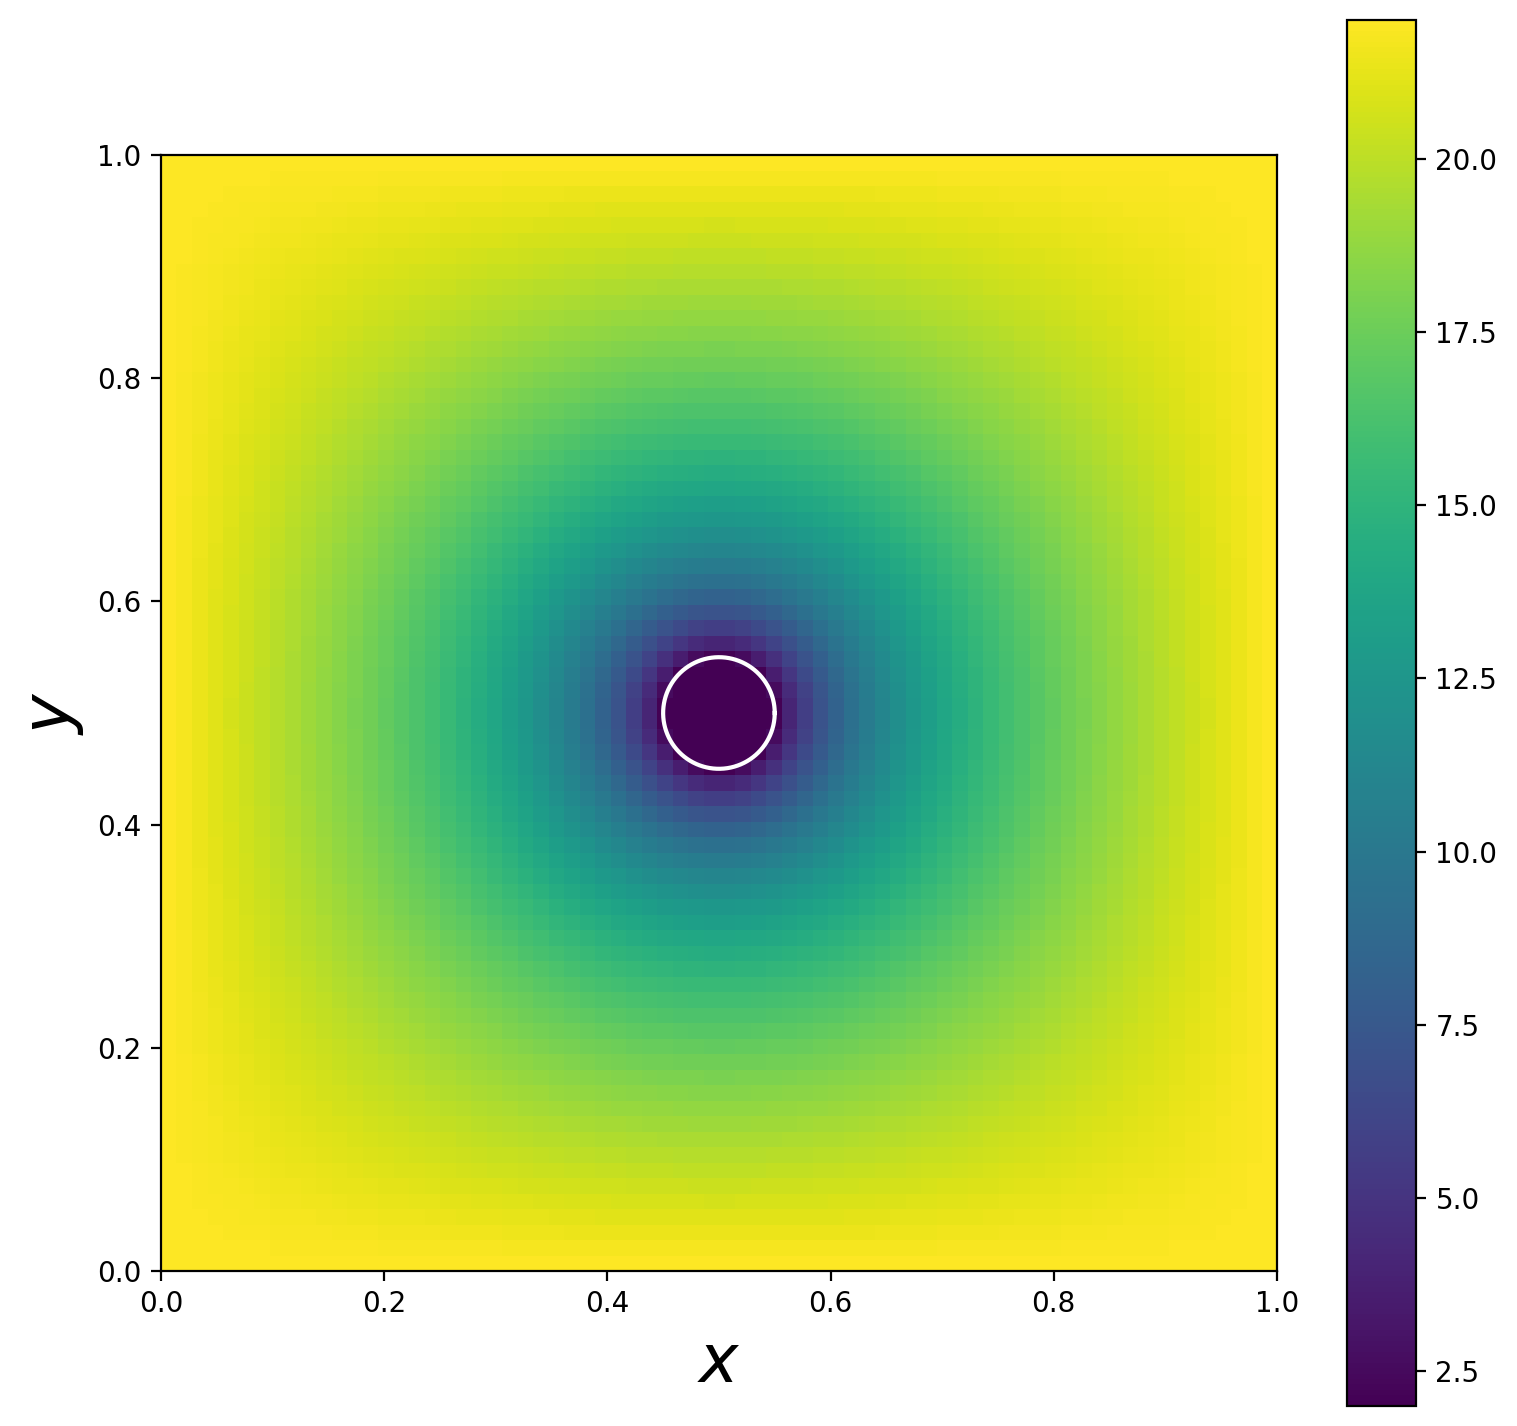

In [30]:
figure(1, [9, 9])
uplot = u.copy()
# uplot[inner_boundary_grid_mask_x] = nan
# uplot[inner_boundary_grid_mask_y] = nan
imshow(uplot, origin='lower', extent=[0, 1, 0, 1])
colorbar()
theta = linspace(0, 2*pi, 200)
plot(0.5 + R*cos(theta), 0.5 + R*sin(theta), 'w')
xlabel(r'$x$', fontsize=24)
ylabel(r'$y$', fontsize=24);

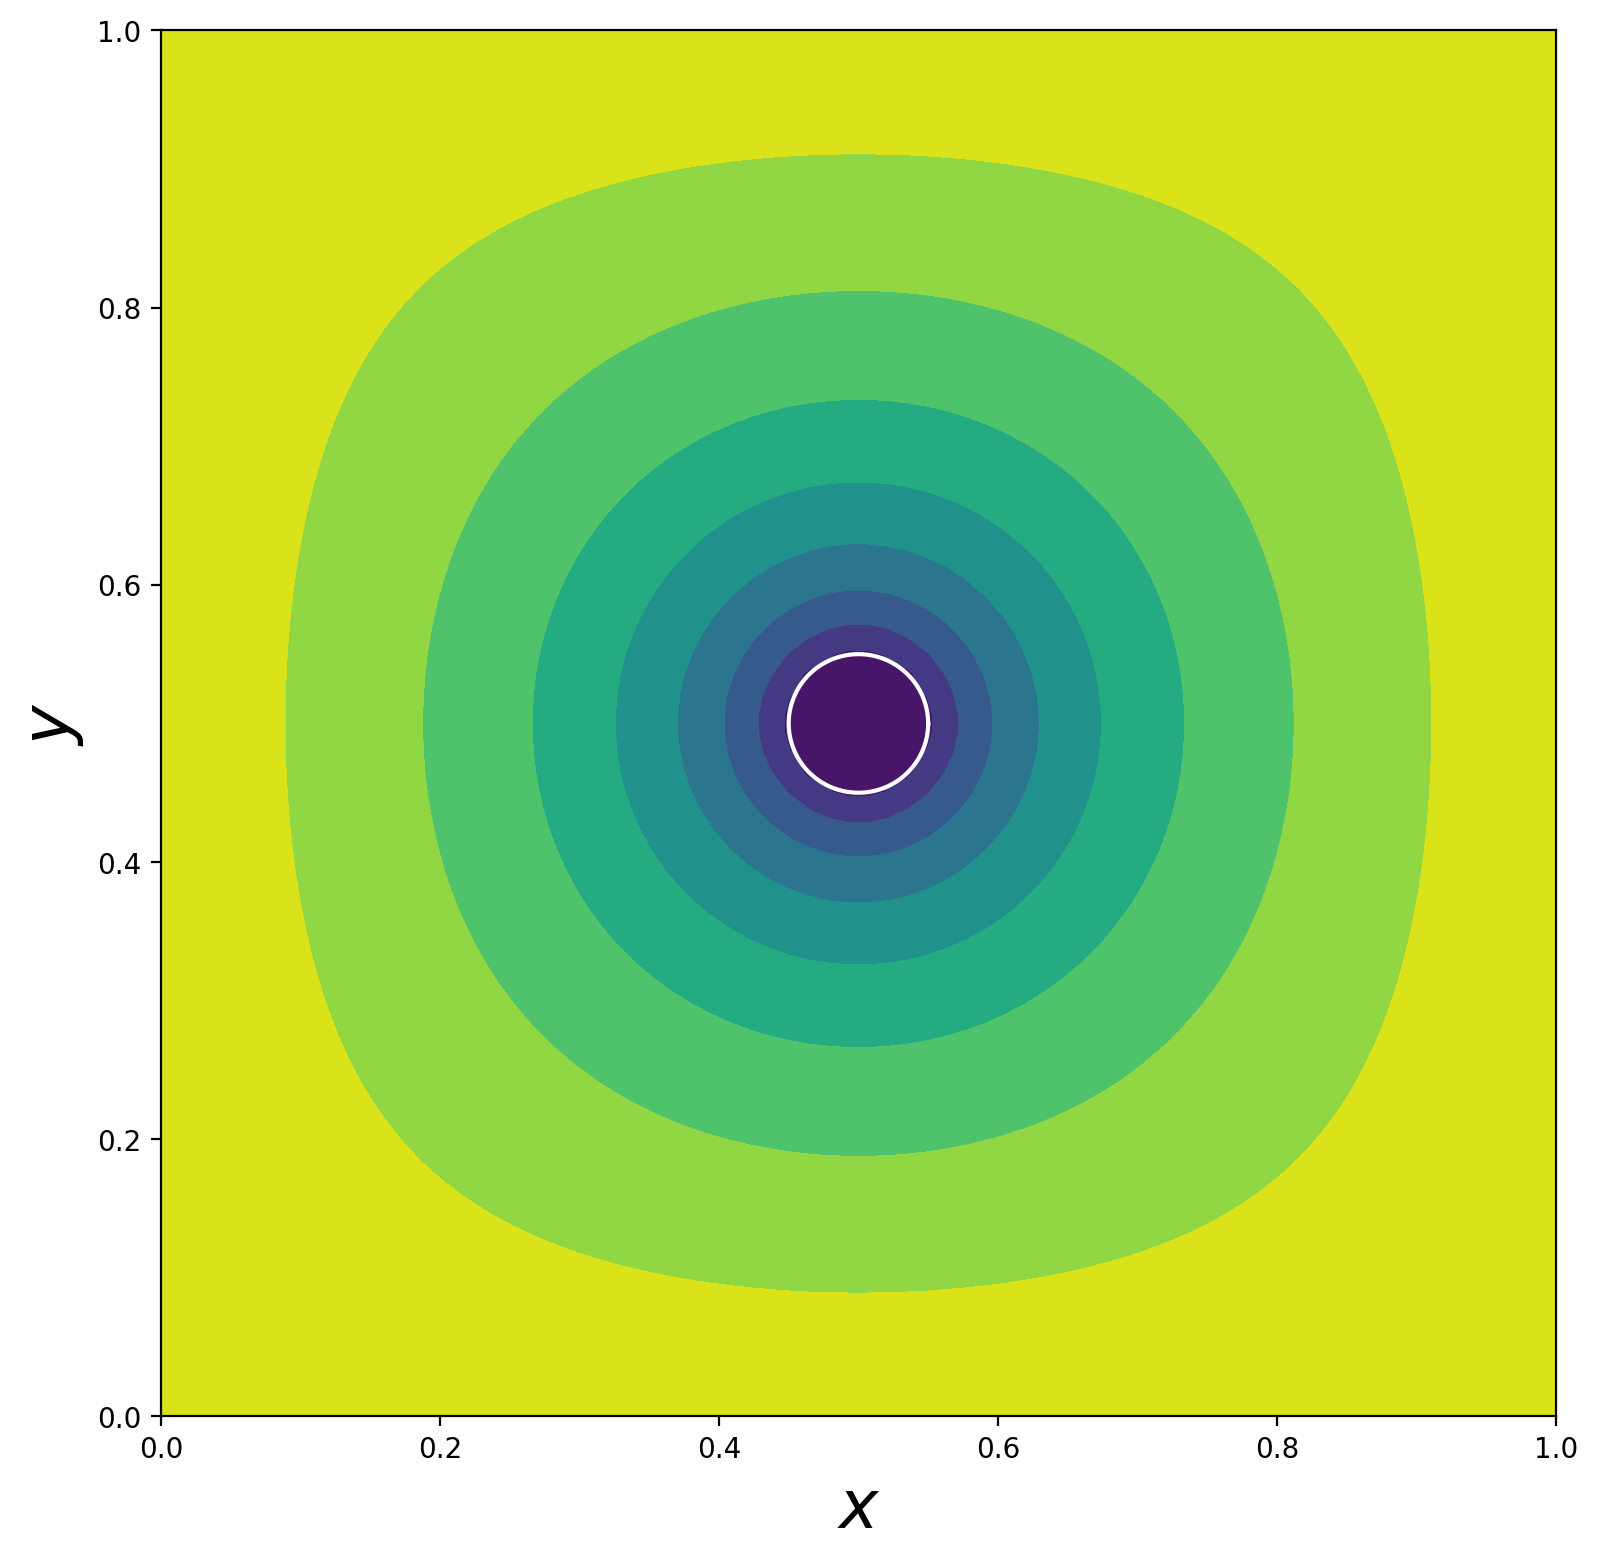

In [31]:
figure(1, [9, 9])
contourf(x, y, u)
# colorbar()
theta = linspace(0, 2*pi, 200)
plot(0.5 + R*cos(theta), 0.5 + R*sin(theta), 'w')
xlabel(r'$x$', fontsize=24)
ylabel(r'$y$', fontsize=24);